# Set up environment

In [1]:
import gymnasium as gym
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from collections import deque

KeyboardInterrupt: 

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [ ]:
class CustomLSTMExtractor(BaseFeaturesExtractor):
    """
    Custom Feature Extractor that uses an LSTM to process the time-series observation.
    
    :param observation_space: (gym.Space) The observation space of the environment.
    :param features_dim: (int) The dimension of the output features from the LSTM.
    """
    def __init__(self, observation_space: gym.spaces.Box, features_dim: int = 128):
        super().__init__(observation_space, features_dim)
        
        self.window_size = observation_space.shape[0]
        self.input_dim = observation_space.shape[1]
        self.lstm = nn.LSTM(input_size=self.input_dim, hidden_size=features_dim, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        
    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        lstm_out, _ = self.lstm(observations)
        last_step_out=lstm_out[:, -1, :]
        last_step_out=self.dropout(last_step_out)
        return last_step_out

# 数据准备

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
tech_daily = pd.read_csv(r"data\科技股票.csv")
tech_daily.set_index('date', inplace=True)
tech_daily.columns=['AAPL','GOOG','MSFT']
tech_daily

,AAPL,GOOG,MSFT
date,,,
2015-11-09,27.184789,35.998153,47.105569
2015-11-10,26.328007,36.168488,46.540233
2015-11-11,26.179197,36.520082,46.661997
2015-11-12,26.091265,36.312999,46.374980
2015-11-13,25.329180,35.606335,45.957501
...,...,...,...
2025-11-24,275.920000,318.470000,474.000000
2025-11-25,276.970000,323.640000,476.990000
2025-11-26,277.550000,320.280000,485.500000


In [ ]:
debt=pd.read_csv(r"data\无风险.csv")
debt.set_index('date', inplace=True)
debt.columns=['US_debt']
debt

,US_debt
date,
2015-11-09,19.950578
2015-11-10,19.974528
2015-11-11,19.934611
2015-11-12,19.982512
2015-11-13,20.030412
...,...
2025-11-24,23.230000
2025-11-25,23.280000
2025-11-26,23.295000


In [ ]:
tmp=pd.read_csv(r"data\指数和贵金属.csv")
tmp.columns=['date','SP500','Gold']
tmp.set_index('date', inplace=True)
tmp

,SP500,Gold
date,,
2015-11-09,2078.58,1090.7
2015-11-10,2081.72,1087.9
2015-11-11,2075.00,1084.2
2015-11-12,2045.97,1083.5
2015-11-13,2023.04,1081.3
...,...,...
2025-11-24,6705.12,4133.8
2025-11-25,6765.88,4126.3
2025-11-26,6812.61,4196.1


In [ ]:
df=pd.merge(tech_daily,debt,how='left',on='date')
df=pd.merge(df,tmp,how='left',on='date')
df['date']=pd.to_datetime(df.index)
df.set_index('date', inplace=True)
df[df.isnull().values == True]

,AAPL,GOOG,MSFT,US_debt,SP500,Gold
date,,,,,,
2017-03-28,33.287503,40.767019,59.093436,20.711540,2358.57,NaN
2017-03-30,33.317596,41.292423,59.473574,20.694991,2368.06,NaN
2017-04-04,33.512043,41.444880,59.491676,20.802890,2360.16,NaN
2017-04-10,33.141667,40.956224,59.310658,20.811185,2357.16,NaN
2018-05-28,NaN,NaN,NaN,NaN,NaN,1297.5
...,...,...,...,...,...,...
2025-11-27,NaN,NaN,NaN,NaN,NaN,4189.6
2025-11-27,NaN,NaN,NaN,NaN,NaN,4189.6
2025-11-27,NaN,NaN,NaN,NaN,NaN,4189.6


In [ ]:
df['Cash']=1 
df

,AAPL,GOOG,MSFT,US_debt,SP500,Gold,Cash
date,,,,,,,
2015-11-09,27.184789,35.998153,47.105569,19.950578,2078.58,1090.7,1
2015-11-10,26.328007,36.168488,46.540233,19.974528,2081.72,1087.9,1
2015-11-11,26.179197,36.520082,46.661997,19.934611,2075.00,1084.2,1
2015-11-12,26.091265,36.312999,46.374980,19.982512,2045.97,1083.5,1
2015-11-13,25.329180,35.606335,45.957501,20.030412,2023.04,1081.3,1
...,...,...,...,...,...,...,...
2025-11-24,275.920000,318.470000,474.000000,23.230000,6705.12,4133.8,1
2025-11-25,276.970000,323.640000,476.990000,23.280000,6765.88,4126.3,1
2025-11-26,277.550000,320.280000,485.500000,23.295000,6812.61,4196.1,1


In [ ]:
df.interpolate(method='time', inplace=True)
df

,AAPL,GOOG,MSFT,US_debt,SP500,Gold,Cash
date,,,,,,,
2015-11-09,27.184789,35.998153,47.105569,19.950578,2078.58,1090.7,1
2015-11-10,26.328007,36.168488,46.540233,19.974528,2081.72,1087.9,1
2015-11-11,26.179197,36.520082,46.661997,19.934611,2075.00,1084.2,1
2015-11-12,26.091265,36.312999,46.374980,19.982512,2045.97,1083.5,1
2015-11-13,25.329180,35.606335,45.957501,20.030412,2023.04,1081.3,1
...,...,...,...,...,...,...,...
2025-11-24,275.920000,318.470000,474.000000,23.230000,6705.12,4133.8,1
2025-11-25,276.970000,323.640000,476.990000,23.280000,6765.88,4126.3,1
2025-11-26,277.550000,320.280000,485.500000,23.295000,6812.61,4196.1,1


In [ ]:
df = df.sort_index()

print("数据日期范围:", df.index.min(), "→", df.index.max())

def generate_walk_forward_windows(index, train_years=9, test_months=12, step_months=6):
    windows = []

    start_date = index.min().normalize()
    last_date = index.max().normalize()

    current_train_start = start_date

    while True:
        train_start = current_train_start
        train_end = (
            train_start + pd.DateOffset(years=train_years) - pd.DateOffset(days=1)
        )
        test_start = train_end + pd.DateOffset(days=1)
        test_end = (
            test_start + pd.DateOffset(months=test_months) - pd.DateOffset(days=1)
        )

        if test_end > last_date:
            break

        windows.append(
            {
                "train_start": train_start,
                "train_end": train_end,
                "test_start": test_start,
                "test_end": test_end,
            }
        )

        current_train_start = current_train_start + pd.DateOffset(months=step_months)

    return windows


# 生成窗口
windows = generate_walk_forward_windows(df.index)

print(f"共生成 {len(windows)} 个滑动窗口：")
for i, w in enumerate(windows):
    print(
        f"Window {i}: "
        f"Train {w['train_start'].date()} ~ {w['train_end'].date()} | "
        f"Test {w['test_start'].date()} ~ {w['test_end'].date()}"
    )

数据日期范围: 2015-11-09 00:00:00 → 2025-11-28 00:00:00
共生成 1 个滑动窗口：
Window 0: Train 2015-11-09 ~ 2024-11-08 | Test 2024-11-09 ~ 2025-11-08


In [ ]:
from math import inf
import talib
import numpy as np
import pandas as pd
import gymnasium as gym
import torch
from collections import deque  # 【修复1】修正导入

class PortfolioOptimizationEnv(gym.Env):
    def __init__(
        self, tickers, window_size, start_date, end_date, initial_balance, lambda_turnover,lambda_softmax,seed=None
    ):
        super().__init__()
        self.tickers = tickers
        self.window_size = window_size
        self.initial_balance = initial_balance
        self.lambda_turnover = lambda_turnover
        self.lambda_softmax = lambda_softmax

        # 分别存储原始价格和指标
        self.raw_data, self.feature_data = self.get_data(tickers, start_date, end_date)
        self.n_features = self.feature_data.shape[1]

        self.action_space = gym.spaces.Box(low=0, high=1, shape=(len(tickers),))
        self.observation_space = gym.spaces.Box(
            low=-inf, high=inf, shape=(window_size, self.n_features)
        )

        self.return_window = deque(maxlen=window_size)
        self.last_action = np.ones(len(tickers)) / len(tickers)

        if seed is not None:
            np.random.seed(seed)
            self.action_space.seed(seed)
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)

    def get_data(self, tickers, start_date, end_date):
        # 假设 df 是全局变量，建议在实际工程中作为参数传入，这里保持原样
        data = df.copy().dropna()
        data = data.loc[start_date:end_date, tickers]

        # 保存原始价格（用于计算投资组合收益）
        raw_data = data.copy()

        # 计算特征指标
        returns = data.pct_change()

        feature_list=[returns]

        volatility=data.pct_change().rolling(window=self.window_size).std()
        volatility.columns=[f'{col}_vol_{self.window_size}' for col in volatility.columns]
        feature_list.append(volatility)

        rsi_df=pd.DataFrame(index=data.index)
        for col in data.columns:
            values=data[col].values.astype(float)

            if np.all(values==values[0]):
                rsi_df[f'{col}_rsi']=50
            else:
                try:
                    rsi_values=talib.RSI(values, timeperiod=14)
                    rsi_df[f'{col}_rsi']=rsi_values
                except Exception as e:
                    print(f'RSI计算失败: {e}')
        feature_list.append(rsi_df)
        
        macd_df=pd.DataFrame(index=data.index)
        for col in data.columns:
            values=data[col].values.astype(float)

            if np.all(values==values[0]):
                macd_df[f'{col}_macd']=0
            else:
                try:
                    macd_values=talib.MACD(values, fastperiod=12, slowperiod=26, signalperiod=9)[0]
                    macd_df[f'{col}_macd']=macd_values
                except Exception as e:
                    print(f'MACD计算失败: {e}')
        feature_list.append(macd_df)

        feature_data=pd.concat(feature_list, axis=1)
        feature_data=feature_data.dropna()
        raw_data=raw_data.reindex(feature_data.index).dropna()

        return raw_data, feature_data

    def reset(self, seed=None):
        self.balance = self.initial_balance
        self.current_step = self.window_size

        self.return_window.clear()
        self.last_action = np.ones(len(self.tickers)) / len(self.tickers)

        # 使用特征数据作为观察
        obs = self.feature_data.iloc[
            self.current_step - self.window_size : self.current_step
        ].values
        info = {"balance": self.balance}
        return obs, info

    def step(self, action):
        # 添加softmax放大赢家通吃结果
        action = np.asarray(action).ravel()
        action = np.exp((action - np.max(action)) / self.lambda_softmax)
        action = action / np.sum(action)

        prev_balance = self.balance

        # 从原始价格计算实际收益
        # 确保 current_step 不越界
        if self.current_step >= len(self.raw_data):
            done = True
            # 返回最后一个有效观察
            obs = self.feature_data.iloc[
                self.current_step - self.window_size : self.current_step
            ].values
            return obs, 0, True, False, {"balance": self.balance}

        current_price = self.raw_data.iloc[self.current_step].values[
            : len(self.tickers)
        ]
        prev_price = self.raw_data.iloc[self.current_step - 1].values[
            : len(self.tickers)
        ]
        asset_returns = current_price / prev_price - 1

        self.return_window.append(asset_returns)

        # 基础奖励：投资组合收益
        portfolio_return = np.sum(asset_returns * action)
        
        volatility = np.std(self.return_window) if len(self.return_window) > 10 else 0.01

        turnover = np.sum(np.abs(action - self.last_action))
        cost = turnover
        self.last_action = action

        # 总奖励
        self.balance = self.balance * (1 + portfolio_return-self.lambda_turnover*turnover)# 添加手续费
        reward = portfolio_return / (volatility + 1e-6) - self.lambda_turnover * turnover

        self.current_step += 1
        done = self.current_step >= len(self.raw_data) - 1

        # 【修复2】修正观察窗口逻辑，与 reset 保持一致，向后看 window_size
        obs = self.feature_data.iloc[
            self.current_step - self.window_size : self.current_step
        ].values

        terminated = bool(done)
        truncated = False
        info = {
            "balance": self.balance,
            "weights": action,
        }

        return obs, reward, terminated, truncated, info

In [ ]:
tickers = df.columns.tolist()
window_size = 5
start_date = '2015-11-09'
end_date = '2025-11-28'
initial_balance = 10000
seed = 8

env = PortfolioOptimizationEnv(
    tickers,
    window_size,
    start_date,
    end_date,
    initial_balance,
    lambda_turnover=0.001,
    lambda_softmax=0.25,
    seed=seed)

# Get the initial state
state = env.reset(seed=seed)
# Sample and execute a random action
action = env.action_space.sample()
next_state, reward, terminated, truncated, info = env.step(action)
done = bool(terminated or truncated)
print(f"Action: {action}")
print(f"Reward: {reward}")
print(f"Balance: {info['balance']}")
print(f"Done: {done}")


Action: [0.32697228 0.98727685 0.31871083 0.78854895 0.86989653 0.39108482
 0.4378819 ]
Reward: -0.133487172155177
Balance: 9986.906196380232
Done: False


# gridsearch lambda

In [ ]:
policy_kwargs = dict(
    features_extractor_class=CustomLSTMExtractor,
    features_extractor_kwargs=dict(features_dim=128), # Output dimension of LSTM
    net_arch=[128, 64] # MLP layers after LSTM
)

In [ ]:
import pandas as pd
import numpy as np
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
import os

lambda_turnover_candidates = [0.001]
lambda_softmax_candidates = [0.25]

grid_search_results = []

w = windows[0]
train_start_str = w["train_start"].strftime("%Y-%m-%d")
train_end_str = w["train_end"].strftime("%Y-%m-%d")
test_start_str = w["test_start"].strftime("%Y-%m-%d")
test_end_str = w["test_end"].strftime("%Y-%m-%d")

print(f"Grid Search on Window 0: Train {train_start_str}~{train_end_str} | Test {test_start_str}~{test_end_str}")

for lam_turnover in lambda_turnover_candidates:
    for lam_softmax in lambda_softmax_candidates:
        print(f"\n>>> Testing lambda_turnover = {lam_turnover}, lambda_softmax = {lam_softmax} ...")
    
        # --- A. 构建训练环境 ---
        def make_train_env():
            return PortfolioOptimizationEnv(
                tickers=tickers,
                window_size=window_size,
                start_date=train_start_str,
                end_date=train_end_str,
                initial_balance=initial_balance,
                lambda_turnover=lam_turnover, 
                lambda_softmax=lam_softmax,
                seed=seed,
            )
            
        vec_train_env = DummyVecEnv([make_train_env])
        # 使用 VecNormalize
        vec_train_env = VecNormalize(vec_train_env, norm_obs=True, norm_reward=False, clip_obs=10.0)

        # --- B. 训练模型 ---
        model = SAC(
            "MlpPolicy",
            vec_train_env,
            verbose=0,
            device=device,
            policy_kwargs=policy_kwargs,
            learning_rate=3e-4,
            batch_size=256,
            buffer_size=200_000,
            gamma=0.99,
            tau=0.005,
            ent_coef=0.00001,
        )

        model.learn(total_timesteps=20000) 

        # --- C. 构建测试环境 ---
        def make_test_env():
            return PortfolioOptimizationEnv(
                tickers=tickers,
                window_size=window_size,
                start_date=test_start_str,
                end_date=test_end_str,
                initial_balance=initial_balance,
                lambda_turnover=lam_turnover,
                lambda_softmax=lam_softmax,
                seed=seed,
            )
        
        test_env_raw = DummyVecEnv([make_test_env])
        # 加载训练时的归一化参数
        test_env = VecNormalize(vec_train_env, test_env_raw)
        test_env.training = False
        test_env.norm_reward = False
        
        # --- D. 回测 ---
        obs = test_env.reset()
        done = False
        balances = []
        weights_history = []
        
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, dones, infos = test_env.step(action)
            done = dones[0]
            balances.append(infos[0]['balance'])
            weights_history.append(infos[0]['weights'])
            
        # --- E. 计算指标 ---
        if len(weights_history) > 1:
            weights_arr = np.array(weights_history)
            turnover_series = np.mean(np.abs(weights_arr[1:] - weights_arr[:-1]), axis=1)
            avg_turnover = np.mean(turnover_series)
        else:
            avg_turnover = 0

        balances_arr = np.array(balances)
        rets = balances_arr[1:] / balances_arr[:-1] - 1.0
        
        total_growth = balances_arr[-1] / balances_arr[0]
        ann_return = np.mean(rets) * 252
        ann_vol = np.std(rets) * np.sqrt(252)
        sharpe = ann_return / ann_vol if ann_vol > 0 else 0
        
        print(f"   Sharpe: {sharpe:.4f} | Return: {ann_return:.2%} | Vol: {ann_vol:.2%} | Turnover: {avg_turnover:.4f}")
        
        grid_search_results.append({
            "lambda_turnover": lam_turnover,
            "lambda_softmax": lam_softmax,
            "sharpe": sharpe,
            "ann_return": ann_return,
            "ann_vol": ann_vol,
            "final_balance": balances_arr[-1],
            "avg_turnover": avg_turnover
        }) 

# 3. 展示结果
print("\n=== Grid Search Results ===")
df_results = pd.DataFrame(grid_search_results)
df_results = df_results.sort_values(by="sharpe", ascending=False)
print(df_results)

Grid Search on Window 0: Train 2015-11-09~2024-11-08 | Test 2024-11-09~2025-11-08

>>> Testing lambda_turnover = 0.001, lambda_softmax = 0.25 ...
   Sharpe: 4.4173 | Return: 71.33% | Vol: 16.15% | Turnover: 0.0652

=== Grid Search Results ===
   lambda_turnover  lambda_softmax    sharpe  ann_return   ann_vol  \
0            0.001            0.25  4.417254    0.713311  0.161483   

   final_balance  avg_turnover  
0   5.381125e+06      0.065236  


网格搜索结果 lambda_turnover=0.001 lambda_softmax=0.25

Grid Search on Window 0: Train 2015-11-09~2024-11-08 | Test 2024-11-09~2025-11-08

>>> Testing lambda_turnover = 0.0001, lambda_softmax = 0.1 ...
   Sharpe: 2.4434 | Return: 39.75% | Vol: 16.27% | Turnover: 0.0607

>>> Testing lambda_turnover = 0.0001, lambda_softmax = 0.25 ...
   Sharpe: 2.3316 | Return: 35.65% | Vol: 15.29% | Turnover: 0.0576

>>> Testing lambda_turnover = 0.0001, lambda_softmax = 0.5 ...
   Sharpe: 2.0343 | Return: 28.04% | Vol: 13.78% | Turnover: 0.0241

>>> Testing lambda_turnover = 0.0001, lambda_softmax = 1.0 ...
   Sharpe: 1.5531 | Return: 21.95% | Vol: 14.14% | Turnover: 0.0158

>>> Testing lambda_turnover = 0.0001, lambda_softmax = 2.5 ...
   Sharpe: 1.2937 | Return: 16.61% | Vol: 12.84% | Turnover: 0.0052

>>> Testing lambda_turnover = 0.0001, lambda_softmax = 5.0 ...
   Sharpe: 1.2034 | Return: 15.70% | Vol: 13.04% | Turnover: 0.0027

>>> Testing lambda_turnover = 0.0001, lambda_softmax = 10.0 ...
   Sharpe: 1.1497 | Return: 14.97% | Vol: 13.02% | Turnover: 0.0011

>>> Testing lambda_turnover = 0.001, lambda_softmax = 0.1 ...
   Sharpe: 2.5819 | Return: 44.52% | Vol: 17.24% | Turnover: 0.0580

>>> Testing lambda_turnover = 0.001, lambda_softmax = 0.25 ...
   Sharpe: 2.5942 | Return: 41.09% | Vol: 15.84% | Turnover: 0.0502

>>> Testing lambda_turnover = 0.001, lambda_softmax = 0.5 ...
   Sharpe: 1.8616 | Return: 28.67% | Vol: 15.40% | Turnover: 0.0373

>>> Testing lambda_turnover = 0.001, lambda_softmax = 1.0 ...
   Sharpe: 1.5226 | Return: 21.13% | Vol: 13.88% | Turnover: 0.0163

>>> Testing lambda_turnover = 0.001, lambda_softmax = 2.5 ...
   Sharpe: 1.2416 | Return: 15.83% | Vol: 12.75% | Turnover: 0.0051

>>> Testing lambda_turnover = 0.001, lambda_softmax = 5.0 ...
   Sharpe: 1.1742 | Return: 15.30% | Vol: 13.03% | Turnover: 0.0025

>>> Testing lambda_turnover = 0.001, lambda_softmax = 10.0 ...
   Sharpe: 1.1549 | Return: 15.07% | Vol: 13.05% | Turnover: 0.0013

>>> Testing lambda_turnover = 0.01, lambda_softmax = 0.1 ...
   Sharpe: 2.1506 | Return: 39.01% | Vol: 18.14% | Turnover: 0.0472

>>> Testing lambda_turnover = 0.01, lambda_softmax = 0.25 ...
   Sharpe: 2.3958 | Return: 41.71% | Vol: 17.41% | Turnover: 0.0534

>>> Testing lambda_turnover = 0.01, lambda_softmax = 0.5 ...
   Sharpe: 1.8251 | Return: 27.07% | Vol: 14.83% | Turnover: 0.0239

>>> Testing lambda_turnover = 0.01, lambda_softmax = 1.0 ...
   Sharpe: 1.3032 | Return: 19.07% | Vol: 14.63% | Turnover: 0.0141

>>> Testing lambda_turnover = 0.01, lambda_softmax = 2.5 ...
   Sharpe: 1.2551 | Return: 16.14% | Vol: 12.86% | Turnover: 0.0053

>>> Testing lambda_turnover = 0.01, lambda_softmax = 5.0 ...
   Sharpe: 1.1710 | Return: 15.48% | Vol: 13.22% | Turnover: 0.0030

>>> Testing lambda_turnover = 0.01, lambda_softmax = 10.0 ...
   Sharpe: 1.1512 | Return: 15.12% | Vol: 13.14% | Turnover: 0.0015

>>> Testing lambda_turnover = 0.1, lambda_softmax = 0.1 ...
   Sharpe: 2.1943 | Return: 40.36% | Vol: 18.39% | Turnover: 0.0451

>>> Testing lambda_turnover = 0.1, lambda_softmax = 0.25 ...
   Sharpe: 2.0799 | Return: 32.91% | Vol: 15.82% | Turnover: 0.0369

>>> Testing lambda_turnover = 0.1, lambda_softmax = 0.5 ...
   Sharpe: 2.3753 | Return: 33.68% | Vol: 14.18% | Turnover: 0.0340

>>> Testing lambda_turnover = 0.1, lambda_softmax = 1.0 ...
   Sharpe: 1.5562 | Return: 19.78% | Vol: 12.71% | Turnover: 0.0156

>>> Testing lambda_turnover = 0.1, lambda_softmax = 2.5 ...
   Sharpe: 1.2635 | Return: 16.40% | Vol: 12.98% | Turnover: 0.0063

>>> Testing lambda_turnover = 0.1, lambda_softmax = 5.0 ...
   Sharpe: 1.1697 | Return: 15.08% | Vol: 12.89% | Turnover: 0.0028

>>> Testing lambda_turnover = 0.1, lambda_softmax = 10.0 ...
   Sharpe: 1.1342 | Return: 14.87% | Vol: 13.11% | Turnover: 0.0011

>>> Testing lambda_turnover = 1, lambda_softmax = 0.1 ...
   Sharpe: 1.6185 | Return: 22.99% | Vol: 14.20% | Turnover: 0.0160

>>> Testing lambda_turnover = 1, lambda_softmax = 0.25 ...
   Sharpe: 1.3400 | Return: 19.40% | Vol: 14.48% | Turnover: 0.0115

>>> Testing lambda_turnover = 1, lambda_softmax = 0.5 ...
   Sharpe: 1.7711 | Return: 23.81% | Vol: 13.44% | Turnover: 0.0168

>>> Testing lambda_turnover = 1, lambda_softmax = 1.0 ...
   Sharpe: 1.4158 | Return: 19.61% | Vol: 13.85% | Turnover: 0.0096

>>> Testing lambda_turnover = 1, lambda_softmax = 2.5 ...
   Sharpe: 1.2196 | Return: 16.33% | Vol: 13.39% | Turnover: 0.0046

>>> Testing lambda_turnover = 1, lambda_softmax = 5.0 ...
   Sharpe: 1.1891 | Return: 15.52% | Vol: 13.05% | Turnover: 0.0028

>>> Testing lambda_turnover = 1, lambda_softmax = 10.0 ...
   Sharpe: 1.1609 | Return: 15.23% | Vol: 13.12% | Turnover: 0.0013

>>> Testing lambda_turnover = 10, lambda_softmax = 0.1 ...
   Sharpe: 1.2150 | Return: 16.07% | Vol: 13.23% | Turnover: 0.0007

>>> Testing lambda_turnover = 10, lambda_softmax = 0.25 ...
   Sharpe: 1.0434 | Return: 11.18% | Vol: 10.72% | Turnover: 0.0006

>>> Testing lambda_turnover = 10, lambda_softmax = 0.5 ...
   Sharpe: 1.1371 | Return: 12.42% | Vol: 10.92% | Turnover: 0.0002

>>> Testing lambda_turnover = 10, lambda_softmax = 1.0 ...
   Sharpe: 1.1463 | Return: 11.76% | Vol: 10.26% | Turnover: 0.0001

>>> Testing lambda_turnover = 10, lambda_softmax = 2.5 ...
   Sharpe: 1.1345 | Return: 13.42% | Vol: 11.83% | Turnover: 0.0003

>>> Testing lambda_turnover = 10, lambda_softmax = 5.0 ...
   Sharpe: 1.1537 | Return: 14.44% | Vol: 12.52% | Turnover: 0.0013

>>> Testing lambda_turnover = 10, lambda_softmax = 10.0 ...
   Sharpe: 1.1497 | Return: 14.92% | Vol: 12.98% | Turnover: 0.0007

=== Grid Search Results ===
    lambda_turnover  lambda_softmax    sharpe  ann_return   ann_vol  \
8            0.0010            0.25  2.594196    0.410939  0.158407   
7            0.0010            0.10  2.581902    0.445184  0.172425   
0            0.0001            0.10  2.443422    0.397540  0.162698   
15           0.0100            0.25  2.395831    0.417086  0.174088   
23           0.1000            0.50  2.375286    0.336755  0.141775   
1            0.0001            0.25  2.331599    0.356524  0.152910   
21           0.1000            0.10  2.194268    0.403634  0.183949   
14           0.0100            0.10  2.150631    0.390096  0.181387   
22           0.1000            0.25  2.079892    0.329097  0.158228   
2            0.0001            0.50  2.034258    0.280409  0.137844   
9            0.0010            0.50  1.861580    0.286660  0.153988   
16           0.0100            0.50  1.825053    0.270720  0.148335   
30           1.0000            0.50  1.771078    0.238079  0.134426   
28           1.0000            0.10  1.618529    0.229890  0.142037   
24           0.1000            1.00  1.556163    0.197778  0.127093   
3            0.0001            1.00  1.553130    0.219547  0.141357   
10           0.0010            1.00  1.522644    0.211305  0.138775   
31           1.0000            1.00  1.415816    0.196080  0.138492   
29           1.0000            0.25  1.339950    0.194021  0.144797   
17           0.0100            1.00  1.303187    0.190668  0.146309   
4            0.0001            2.50  1.293730    0.166052  0.128351   
25           0.1000            2.50  1.263512    0.164024  0.129816   
18           0.0100            2.50  1.255093    0.161445  0.128632   
11           0.0010            2.50  1.241605    0.158285  0.127484   
32           1.0000            2.50  1.219568    0.163302  0.133901   
35          10.0000            0.10  1.215025    0.160705  0.132265   
5            0.0001            5.00  1.203362    0.156957  0.130432   
33           1.0000            5.00  1.189100    0.155195  0.130515   
12           0.0010            5.00  1.174245    0.152952  0.130255   
19           0.0100            5.00  1.171043    0.154784  0.132177   
26           0.1000            5.00  1.169695    0.150820  0.128940   
34           1.0000           10.00  1.160870    0.152302  0.131196   
13           0.0010           10.00  1.154902    0.150738  0.130520   
40          10.0000            5.00  1.153697    0.144418  0.125178   
20           0.0100           10.00  1.151179    0.151231  0.131371   
41          10.0000           10.00  1.149748    0.149203  0.129770   
6            0.0001           10.00  1.149712    0.149718  0.130222   
38          10.0000            1.00  1.146307    0.117643  0.102628   
37          10.0000            0.50  1.137070    0.124173  0.109204   
39          10.0000            2.50  1.134461    0.134163  0.118261   
27           0.1000           10.00  1.134229    0.148677  0.131082   
36          10.0000            0.25  1.043437    0.111829  0.107173   

    final_balance  avg_turnover  
8   358774.935482      0.050217  
7   475418.346175      0.058008  
0   314399.434289      0.060658  
15  370508.885052      0.053381  
23  188407.328159      0.033951  
1   220575.228835      0.057571  
21  321033.809191      0.045101  
14  287478.191610      0.047219  
22  172266.229690      0.036909  
2   114113.162852      0.024072  
9   118200.530983      0.037286  
16  103135.548249      0.023941  
30   78451.631037      0.016795  
28   72258.367922      0.016041  
24   54988.927781      0.015610  
3    65700.133039      0.015813  
10   61220.233755      0.016267  
31   53428.859055      0.009621  
29   52136.244899      0.011469  
17   50342.782439      0.014085  
4    41226.973786      0.005168  
25   40427.205222      0.006288  
18   39545.876913      0.005319  
11   38499.720561      0.005106  
32   39976.285613      0.004607  
35   38972.961136      0.000671  
5    37889.470185      0.002736  
33   37286.958320      0.002810  
12   36534.310005      0.002464  
19   37084.881780      0.002972  
26   35925.500843      0.002796  
34   36302.474173      0.001258  
13   35818.932578      0.001279  
40   34065.766540      0.001268  
20   35929.209766      0.001463  
41   35366.033959      0.000728  
6    35510.909918      0.001097  
38   27435.891368      0.000067  
37   28946.183195      0.000203  
39   31308.075869      0.000251  
27   35143.325878      0.001072  
36   25980.603684      0.000564

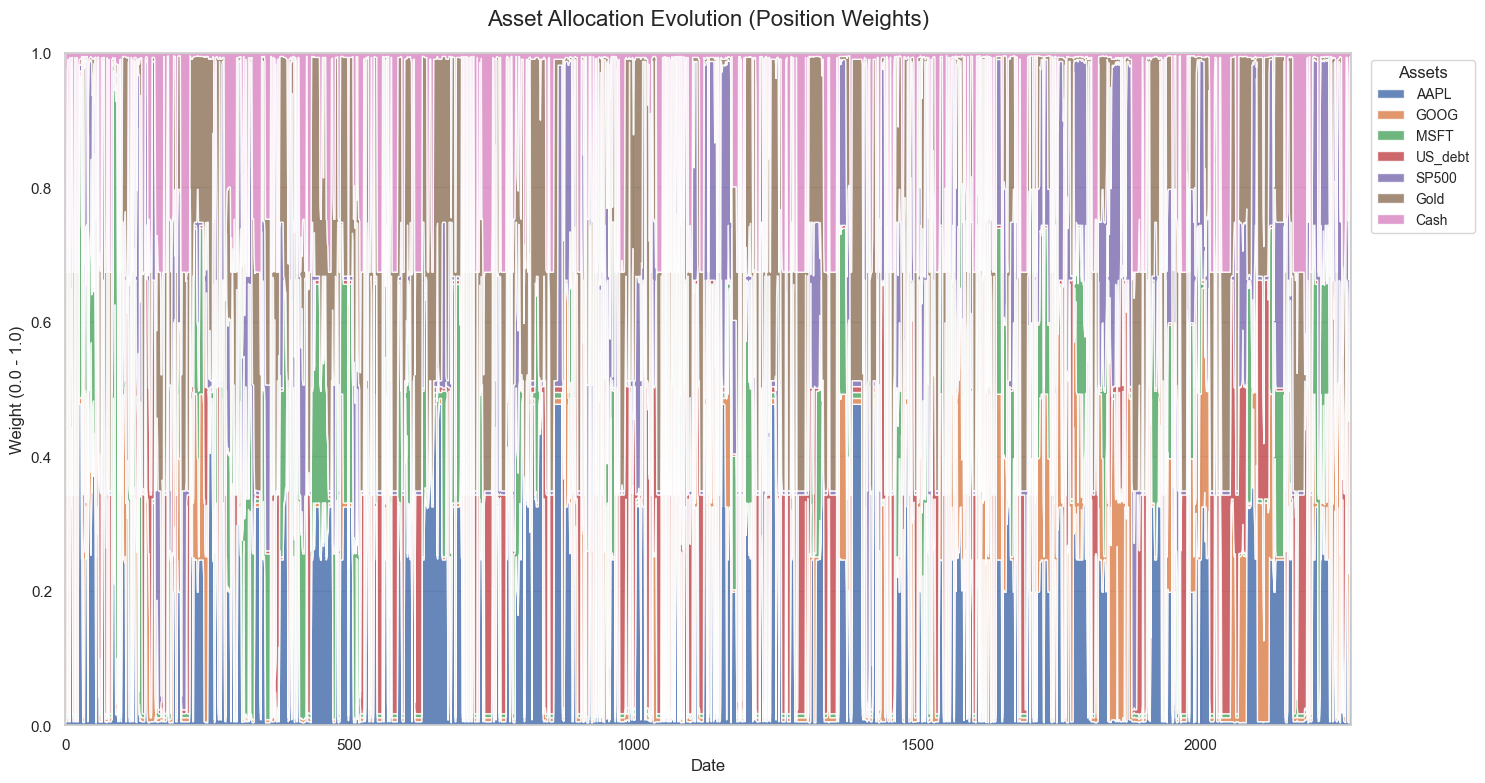


=== Position Statistics ===
Average Position:
Gold       0.223977
AAPL       0.169238
SP500      0.147884
US_debt    0.128008
Cash       0.115140
MSFT       0.110185
GOOG       0.105569

Max Single Position: 90.10% (Gold)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# 设置绘图风格
sns.set_theme(style="whitegrid")

# 1. 准备数据
# 假设 weights_history 是一个包含 numpy array 的列表
# 假设 tickers 是资产名称列表 ['AAPL', 'GOOG', ...]
# 假设 dates 是对应的时间索引

# 确保数据对齐
if len(weights_history) > 0:
    # 将权重转换为 DataFrame
    df_weights = pd.DataFrame(weights_history, columns=tickers)
    
    # 如果有日期数据，设置为索引
    if 'dates' in locals() and len(dates) >= len(df_weights):
        df_weights.index = dates[:len(df_weights)]
    
    # 2. 绘制堆叠图
    plt.figure(figsize=(15, 8))
    
    # 使用 stackplot
    plt.stackplot(df_weights.index, df_weights.T, labels=df_weights.columns, alpha=0.85)
    
    # 3. 美化图表
    plt.title("Asset Allocation Evolution (Position Weights)", fontsize=16, pad=20)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Weight (0.0 - 1.0)", fontsize=12)
    plt.ylim(0, 1.0) # 权重总和应该是 1
    plt.margins(x=0) # 让图表紧贴左右边缘
    
    # 图例放在图表外侧，避免遮挡
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=10, title="Assets")
    
    plt.tight_layout()
    plt.show()
    
    # 4. (可选) 打印统计摘要
    print("\n=== Position Statistics ===")
    print(f"Average Position:\n{df_weights.mean().sort_values(ascending=False).to_string()}")
    print(f"\nMax Single Position: {df_weights.max().max():.2%} ({df_weights.max().idxmax()})")

else:
    print("Error: No weights history found. Please run the backtest loop first.")